# <font color="darkblue"> Exercídio 01: Tendência e Sazonaidade - COVID19 </font>

**Objetivos:**


*   Extair a tedência e a sazonalidade da série temporal de novos casos do COVID 19 no Brasil
*   Testar o conceito da regressão linear para a obtenção tendência e sazonalidade

**Requisitos de execução:**


*   Upload do arquivo *read_covid.py*
*   Criar o diretório *data* e upload do arquivo *covid.csv* neste diretório

**Atividade 1:**

Leia a série temporal do novo casos de COVID 19 no Brasil contida no arquivo *covid.xls* e plote seus valores em um gráfico de barras.









c:\Users\vinic\Machine_learning_exercises\Second_Practical_Lesson\read_covid.py:26: DtypeWarning: Columns (0: populacaoTCU2019) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv(url, sep=';')


Empty DataFrame
Columns: [regiao, estado, municipio, coduf, codmun, codRegiaoSaude, nomeRegiaoSaude, data, semanaEpi, populacaoTCU2019, casosAcumulado, casosNovos, obitosAcumulado, obitosNovos, Recuperadosnovos, emAcompanhamentoNovos]
Index: []


<BarContainer object of 99 artists>

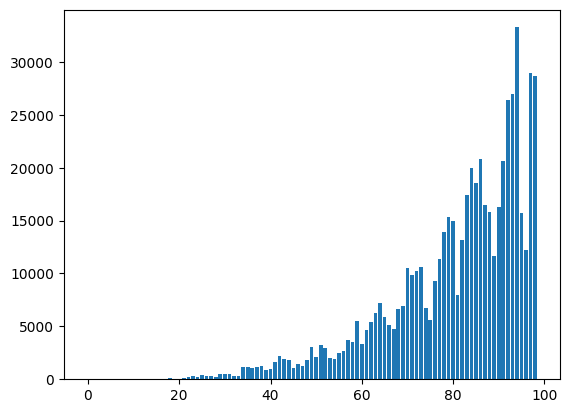

In [1]:
from read_covid import ReadCovid
from matplotlib import pyplot as plt

rd = ReadCovid()
covid = rd.read_csv()

time = covid[ReadCovid.tempo]
data = covid[ReadCovid.casos_novos]

plt.bar(time, data)
    

**Atividade 2:**

Extrai as componenetes tendência e sazonalidade da serie temporal do COVID 19 no Brasil, plotando estas componenetes em gráficos de dispersão sobre o gráfico de barras da série temporal.  Utilize a função *seasonal_decompose* do pacote statsmodels.tsa.seasonal.

**from statsmodels.tsa.seasonal import seasonal_decompose**

Utilize os parâmetros model='additive' e freq=7 na função *seasonal_decompose*.

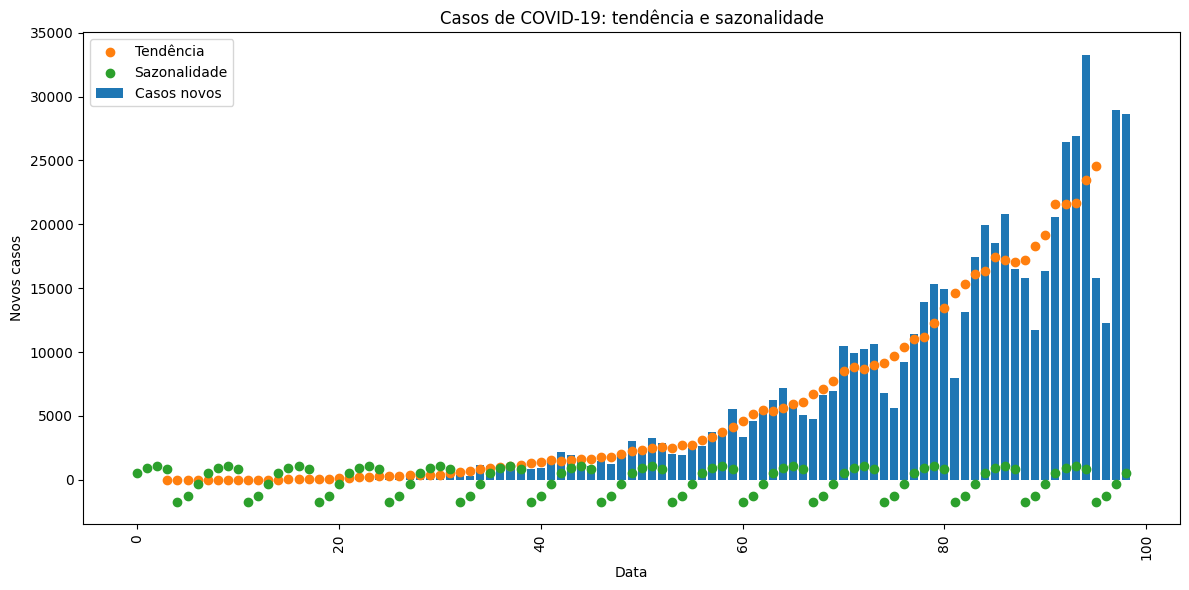

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompor a série em tendência, sazonalidade e resíduos
result = seasonal_decompose(
    data,
    model='additive',
    period=7
)

# Separar os componentes
trend = result.trend
seasonal = result.seasonal

# Criar o gráfico
plt.figure(figsize=(12, 6))

# Série original em barras
plt.bar(time, data, label='Casos novos')

# Tendência e sazonalidade em dispersão
plt.scatter(time, trend, label='Tendência')
plt.scatter(time, seasonal, label='Sazonalidade')

# Configurações visuais
plt.title('Casos de COVID-19: tendência e sazonalidade')
plt.xlabel('Data')
plt.ylabel('Novos casos')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

# Exibir
plt.show()